In [1]:
# ΚΕΛΙ 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Εισαγωγή των δικών σου συναρτήσεων
from utils import list_files_in_folder, encode_labels
from utils_visual import plot_heatmap, plot_instance_3d, plot_scatter_pca
from sklearn.feature_selection import VarianceThreshold

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12,6)

In [2]:
# ΚΕΛΙ 2
folder_path = "data"
# Διαβάζει τον φάκελο data και φτιάχνει
# μια λίστα με τα ονόματα όλων των αρχείων που τελειώνουν σε .csv.
files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]

df_list = []

#Λούπα που μπαίνει σε κάθε αρχείο ξεχωριστά,
#το διαβάζει ως αυτόνομο DataFrame (pd.read_csv) και το αποθηκεύει προσωρινά στη λίστα df_list.
for file in files:
    temp_df = pd.read_csv(os.path.join(folder_path, file))
    df_list.append(temp_df)

#Το πιο σημαντικό βήμα. Παίρνει όλα τα ξεχωριστά DataFrames από τη λίστα
#και τα «κολλάει» το ένα κάτω από το άλλο (κάθετα), δημιουργώντας ένα τεράστιο, ενιαίο DataFrame df.
#Το ignore_index=True επαναφέρει την αρίθμηση των γραμμών από το 0 έως το σύνολο όλων των γραμμών,
#ώστε να μην υπάρχουν διπλοί δείκτες (indexes).
df = pd.concat(df_list, ignore_index=True)

#Αφαιρεί τυχόν κρυφούς αρχικούς ή τελικούς κενούς χώρους (spaces) από τα ονόματα των στηλών.
df.columns = df.columns.str.strip()

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [21]:
# ΚΕΛΙ 3 - Πλήρης Εμφάνιση Όλων των Στηλών σε Διαδραστικό Πίνακα
import IPython.display as display

print("="*60)
print(f" ΔΙΑΣΤΑΣΕΙΣ DATASET: {df.shape[0]:,} γραμμές | {df.shape[1]} στήλες")
print("="*60)

# Ρύθμιση Pandas για απεριορίστα rows στην HTML εμφάνιση
pd.set_option('display.max_rows', None)

# Δημιουργία του πίνακα
all_features = pd.DataFrame({
    'Α/Α': range(1, len(df.columns) + 1),
    'Όνομα Χαρακτηριστικού (Column Name)': df.columns,
    'Τύπος Δεδομένων (Dtype)': df.dtypes.values
})

# Εμφάνιση ως κανονικός πίνακας Jupyter (HTML DataFrame) αντί για απλό print string
display.display(all_features)

# Επαναφορά ρυθμίσεων
pd.reset_option('display.max_rows')

print("="*60)
memory_gb = df.memory_usage(deep=True).sum() / (1024**3)
print(f" Συνολική Χρήση Μνήμης RAM: {memory_gb:.2f} GB")
print("="*60)

 ΔΙΑΣΤΑΣΕΙΣ DATASET: 2,520,798 γραμμές | 79 στήλες


,Α/Α,Όνομα Χαρακτηριστικού (Column Name),Τύπος Δεδομένων (Dtype)
0,1,Destination Port,int64
1,2,Flow Duration,int64
2,3,Total Fwd Packets,int64
3,4,Total Backward Packets,int64
4,5,Total Length of Fwd Packets,int64
5,6,Total Length of Bwd Packets,int64
6,7,Fwd Packet Length Max,int64
7,8,Fwd Packet Length Min,int64
8,9,Fwd Packet Length Mean,float64
9,10,Fwd Packet Length Std,float64


 Συνολική Χρήση Μνήμης RAM: 1.52 GB


Ομαδοποιήση και επεξήγηση των στηλών των CSV αρχείων

1. Identification Features
Στήλες: Destination Port

Περιγραφή: Προσδιορίζει τη θύρα προορισμού της σύνδεσης, δείχνοντας ποια συγκεκριμένη υπηρεσία στοχεύει η κίνηση.

2. Temporal Features
Στήλες: Flow Duration, Flow IAT Mean, Flow IAT Std, Flow IAT Max, Flow IAT Min, Fwd IAT Total, Fwd IAT Mean, Fwd IAT Std, Fwd IAT Max, Fwd IAT Min, Bwd IAT Total, Bwd IAT Mean, Bwd IAT Std, Bwd IAT Max, Bwd IAT Min, Active Mean, Active Std, Active Max, Active Min, Idle Mean, Idle Std, Idle Max, Idle Min

Περιγραφή: Μετρούν τη συνολική διάρκεια της ροής, τους ενδιάμεσους χρόνους (IAT) μεταξύ των πακέτων και τους χρόνους που η σύνδεση ήταν ενεργή (Active) ή σε αδράνεια (Idle).

3. Volume and Throughput Features
Στήλες: Total Fwd Packets, Total Backward Packets, Total Length of Fwd Packets, Total Length of Bwd Packets, Flow Bytes/s, Flow Packets/s, Fwd Packets/s, Bwd Packets/s, Subflow Fwd Packets, Subflow Fwd Bytes, Subflow Bwd Packets, Subflow Bwd Bytes, Fwd Avg Bytes/Bulk, Fwd Avg Packets/Bulk, Fwd Avg Bulk Rate, Bwd Avg Bytes/Bulk, Bwd Avg Packets/Bulk, Bwd Avg Bulk Rate

Περιγραφή: Καταγράφουν το πλήθος των πακέτων και τον όγκο των δεδομένων σε Bytes (συνολικά, ανά δευτερόλεπτο ή ανά υποροή/Subflow), αναδεικνύοντας τις απότομες και τεράστιες αυξήσεις κίνησης.

4. Statistical Size Features
Στήλες: Fwd Packet Length Max, Fwd Packet Length Min, Fwd Packet Length Mean, Fwd Packet Length Std, Bwd Packet Length Max, Bwd Packet Length Min, Bwd Packet Length Mean, Bwd Packet Length Std, Min Packet Length, Max Packet Length, Packet Length Mean, Packet Length Std, Packet Length Variance, Average Packet Size  

Περιγραφή: Περιγράφουν στατιστικά (μέσο όρο, διακύμανση, μέγιστα/ελάχιστα) το μέγεθος των πακέτων σε bytes, βοηθώντας στον εντοπισμό επιθέσεων που χρησιμοποιούν ασυνήθιστα μικρά ή σταθερά πακέτα.

5. Protocol Flags and Control Features
Στήλες: Fwd PSH Flags, Bwd PSH Flags, Fwd URG Flags, Bwd URG Flags, Fwd Header Length, Bwd Header Length, FIN Flag Count, SYN Flag Count, RST Flag Count, PSH Flag Count, ACK Flag Count, URG Flag Count, CWE Flag Count, ECE Flag Count, Down/Up Ratio, Avg Fwd Segment Size, Avg Bwd Segment Size, Fwd Header Length.1, Init_Win_bytes_forward, Init_Win_bytes_backward, act_data_pkt_fwd, min_seg_size_forward

Περιγραφή: Μετρούν το μέγεθος των κεφαλίδων (Headers) και την εμφάνιση των ειδικών σημάτων ελέγχου (TCP Flags), τα οποία είναι κρίσιμα γιατί οι επιθέσεις (π.χ. SYN Flood) συχνά παραβιάζουν αυτούς τους κανόνες επικοινωνίας.

6. Target Variable
Στήλες: Label

Περιγραφή: Η ετικέτα που ορίζει αν η δικτυακή ροή είναι καθαρή (BENIGN) ή αν αποτελεί συγκεκριμένο τύπο κυβερνοεπίθεσης (DDoS).

In [ ]:
# ΚΕΛΙ 4 
# Έλεγχος για Missing Values και Duplicates
print("\nTotal Missing Values:")
print(df.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())


Total Missing Values:
0

Duplicate Rows:
0


In [ ]:
# ΚΕΛΙ 5
# Remove duplicates
df.drop_duplicates(inplace=True)

# Replace inf values with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Remove missing values
df.dropna(inplace=True)

print("Final Shape After Cleaning:", df.shape)

Final Shape After Cleaning: (2520798, 79)


Διαχείριση και Αιτιολόγηση Καθαρισμού Δεδομένων
1. Τεχνική drop_duplicates: Επιλέχθηκε η άμεση διαγραφή των διπλότυπων αντί για τη διατήρησή τους, καθώς οι πανομοιότυπες εγγραφές στο ίδιο microsecond αποτελούν πλεονασμό του συστήματος καταγραφής. Η αφαίρεσή τους είναι η μοναδική λύση για τον πλήρη αποκλεισμό του Data Leakage.

2. Τεχνική replace για inf τιμές: Οι άπειρες τιμές (inf), που προκύπτουν από διαιρέσεις με το μηδέν 
(π.χ. σε ροές με μηδενική διάρκεια), μετατράπηκαν σε ελλιπείς τιμές (NaN) και στη συνέχεια αφαιρέθηκαν , καθώς η παρουσία τους θα προκαλεί σφάλματα (errors) κατά την εκτέλεση των μαθηματικών αλγορίθμων μηχανικής μάθησης στη συνέχεια.

3. Τεχνική dropna NaN: Επιλέχθηκε η πλήρης αφαίρεση των γραμμών αυτών αντί για τεχνικές συμπλήρωσης (όπως interpolation ή μέσος όρος). Η συμπλήρωση με τεχνητές τιμές σε δικτυακές ροές θα εισήγαγε πλασματικά δεδομένα που θα αλλοίωναν τα πραγματικά χαρακτηριστικά των επιθέσεων
(ειδικά αν μια γραμμή ήταν ενδιάμεσα μιας benign και μιας ddos), ενώ η αφαίρεσή τους είναι ασφαλής λόγω του ελάχιστου πλήθους τους στο dataset.

In [27]:
# ΚΕΛΙ 6 - Πλήρης Στατιστική Περιγραφή σε Διαδραστικό Πίνακα
import IPython.display as display

print(" ΥΠΟΛΟΓΙΣΜΟΣ ΣΥΓΚΕΝΤΡΩΤΙΚΩΝ ΣΤΑΤΙΣΤΙΚΩΝ ΜΕΓΕΘΩΝ")

# Ρύθμιση Pandas ώστε να εμφανίσει όλες τις 78 γραμμές των στατιστικών
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Υπολογισμός των στατιστικών και αναστροφή (Transpose)
stats = df.describe().T

# Στρογγυλοποίηση των δεκαδικών σε 2 ψηφία για να μην βγαίνουν scientific notations (e+03 κλπ)
stats = stats.round(2)

# Εμφάνιση ως κανονικός πίνακας Jupyter (HTML DataFrame)
display.display(stats)

# Επαναφορά αρχικών ρυθμίσεων
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')

 ΥΠΟΛΟΓΙΣΜΟΣ ΣΥΓΚΕΝΤΡΩΤΙΚΩΝ ΣΤΑΤΙΣΤΙΚΩΝ ΜΕΓΕΘΩΝ


,count,mean,std,min,25%,50%,75%,max
Destination Port,2520798.0,8690.59,19012.80,0.000000e+00,53.00,80.00,443.00,6.553500e+04
Flow Duration,2520798.0,16591611.46,35232762.93,-1.300000e+01,208.00,50622.00,5333340.50,1.200000e+08
Total Fwd Packets,2520798.0,10.28,794.42,1.000000e+00,2.00,2.00,6.00,2.197590e+05
Total Backward Packets,2520798.0,11.57,1056.92,0.000000e+00,1.00,2.00,5.00,2.919220e+05
Total Length of Fwd Packets,2520798.0,611.95,10588.27,0.000000e+00,12.00,66.00,332.00,1.290000e+07
Total Length of Bwd Packets,2520798.0,18144.40,2398177.40,0.000000e+00,6.00,156.00,997.00,6.554530e+08
Fwd Packet Length Max,2520798.0,231.23,756.38,0.000000e+00,6.00,40.00,202.00,2.482000e+04
Fwd Packet Length Min,2520798.0,19.20,60.80,0.000000e+00,0.00,2.00,37.00,2.325000e+03
Fwd Packet Length Mean,2520798.0,63.50,195.55,0.000000e+00,6.00,36.25,52.00,5.940860e+03
Fwd Packet Length Std,2520798.0,77.32,296.88,0.000000e+00,0.00,0.00,74.19,7.125600e+03


Στατιστική Περιγραφή και Ερμηνεία των Χαρακτηριστικών

Με την εφαρμογή της μεθόδου df.describe().T, υπολογίστηκαν τα βασικά συγκεντρωτικά στατιστικά μεγέθη (μέσος όρος, τυπική απόκλιση, ακραίες τιμές και τεταρτημόρια) για κάθε αριθμητική μεταβλητή. Από τη μελέτη του πλήρους πίνακα προκύπτουν τα εξής κύρια συμπεράσματα: 

1. Ύπαρξη Τεχνικών Σφαλμάτων (Data Bug): Π.χ. στη στήλη Flow Duration εντοπίστηκε ελάχιστη τιμή (min) ίση με -1.300000e+01. Επειδή η χρονική διάρκεια δεν μπορεί να είναι αρνητική, αυτό αποτελεί γνωστό πρόβλημα καταγραφής του εργαλείου CICFlowMeter λόγω προβλημάτων συγχρονισμού των πακέτων κατά τη διάρκεια έντονης δικτυακής συμφόρησης (π.χ. κατά τη διάρκεια επιθέσεων).

2. Έντονη Ασυμμετρία Κατανομών (Skewness): Σε χαρακτηριστικά όπως το Flow Duration, ο μέσος όρος
(mean = 16.591.610 μs) είναι εξαιρετικά μεγαλύτερος από τη διάμεσο (50% = 50.622 μs). Αυτό δείχνει ότι η πλειοψηφία των ροών ολοκληρώνεται σε κλάσματα του δευτερολέπτου, αλλά υπάρχει ένας μικρός αριθμός ροών με τεράστια διάρκεια (κοντά στο max) που παρασύρει τον μέσο όρο προς τα δεξιά.

3. Ανομοιογένεια στα Μεγέθη Πακέτων: Η πολύ υψηλή τυπική απόκλιση (std) σε μεταβλητές όπως το Packet Length Std και Max Packet Length δείχνει ότι το dataset περιλαμβάνει τόσο πολύ μικρά, επαναλαμβανόμενα πακέτα (χαρακτηριστικό αυτοματοποιημένων επιθέσεων ή scans) όσο και πολύ μεγάλα πακέτα (χαρακτηριστικό κανονικής μεταφοράς αρχείων/web browsing).

4. Κυριαρχία Υπηρεσιών Ιστού: Στη μεταβλητή Destination Port, τα τεταρτημόρια δείχνουν ότι το μεγαλύτερο μέρος της κίνησης συγκεντρώνεται στις θύρες 53 (DNS), 80 (HTTP) και 443 (HTTPS), κάτι που είναι απόλυτα αναμενόμενο για τη φυσιολογική λειτουργία ενός εταιρικού δικτύου.

ΟΠΤΙΚΟΠΟΙΗΣΗ ΧΑΡΑΚΤΗΡΙΣΤΙΚΟΥ: Flow Duration


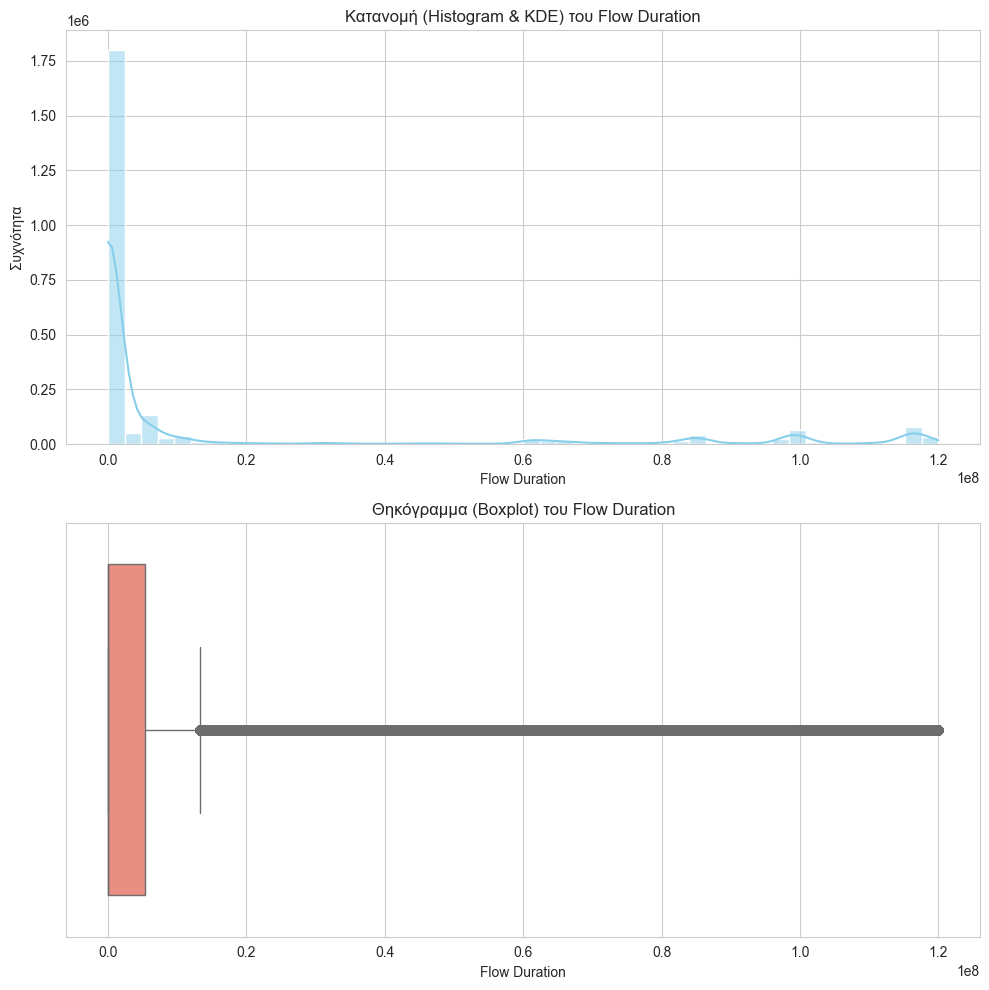

In [52]:
# ΚΕΛΙ 6.1 - Οπτικοποίηση για το Flow Duration (Κατακόρυφη Διάταξη)
import matplotlib.pyplot as plt
import seaborn as sns

print("ΟΠΤΙΚΟΠΟΙΗΣΗ ΧΑΡΑΚΤΗΡΙΣΤΙΚΟΥ: Flow Duration")

# Ορισμός: 2 γραμμές, 1 στήλη, μεγαλύτερο ύψος (10) για να είναι το ένα κάτω από το άλλο
fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# 1. Ιστόγραμμα / Διάγραμμα Πυκνότητας (Πρώτο γράφημα - πάνω)
sns.histplot(data=df, x='Flow Duration', kde=True, bins=50, ax=axes[0], color='skyblue')
axes[0].set_title('Κατανομή (Histogram & KDE) του Flow Duration')
axes[0].set_xlabel('Flow Duration')
axes[0].set_ylabel('Συχνότητα')
# axes[0].set_yscale('log') # Βγάλτε το '#' αν χρειαστεί λογαριθμική κλίμακα λόγω outliers

# 2. Θηκόγραμμα (Δεύτερο γράφημα - κάτω)
sns.boxplot(data=df, x='Flow Duration', ax=axes[1], color='salmon')
axes[1].set_title('Θηκόγραμμα (Boxplot) του Flow Duration')
axes[1].set_xlabel('Flow Duration')

# Αυτόματη διευθέτηση του χώρου ώστε να μην κρύβονται οι τίτλοι
plt.tight_layout()
plt.show()

1) Παρατηρήσεις
Άξονες και Συχνότητα: Στο ιστόγραμμα, ο άξονας Χ δείχνει τη διάρκεια σε κανονικά νανοδευτερόλεπτα/μιλιδευτερόλεπτα (γραμμική κλίμακα από 0 έως 1.2x10^8) και ο άξονας Υ τη συχνότητα. Παρατηρούμε ότι η πρώτη μπάρα αριστερά ξεπερνά τις 1.75x10^6 εγγραφές, δείχνοντας ότι η πλειοψηφία των δεδομένων είναι συγκεντρωμένη σε εκείνο το σημείο.
Ακραία Δεξιά Ασυμμετρία (Right Skewness): Η μπλε γραμμή (KDE) ξεκινά από ένα τεράστιο «βουνό» στα αριστερά και πέφτει ακαριαία, σχηματίζοντας μια πολύ μακριά, άδεια και επίπεδη ουρά που φτάνει μέχρι το τέρμα δεξιά.
Η Συμπεριφορά στο Boxplot: Λόγω αυτής της ασυμμετρίας, το ροζ κουτί (που αντιπροσωπεύει το κεντρικό 50% των δεδομένων) έχει συμπιεστεί εντελώς στην αρχή του άξονα. Το δεξί του «μαύρηχοντρή γραμμή» σταματά πολύ νωρίς (κοντά στο 1.2x10^7). 

2) Μορφή και συγκεκριμένα μοτίβα
Μοτίβο Συσσωρευμένων Ακραίων Τιμών (Outliers): Μετά το κενό, εμφανίζεται μια πολύ χοντρή, συμπαγής μαύρη οριζόντια γραμμή που εκτείνεται μέχρι το 1.2x10^8. Αυτή η γραμμή αποτελείται από χιλιάδες συνεχόμενες τελείες (outliers) που είναι πολύ κοντά η μία στην άλλη. 
Ερμηνεία: Αυτό το μοτίβο προδίδει την ύπαρξη δύο ξεχωριστών κόσμων. Οι ροές κοντά στο μηδέν (αριστερά) περιλαμβάνουν την κανονική κίνηση και γρήγορες επιθέσεις όπως τα Port Scans, ενώ η συμπαγής μαύρη γραμμή των outliers (δεξιά) αποτυπώνει ροές με τεράστια διάρκεια, οι οποίες αποτελούν την κύρια ένδειξη για επιθέσεις τύπου DoS/DDoS (που κρατούν τις συνδέσεις ανοιχτές για ώρες).

ΟΠΤΙΚΟΠΟΙΗΣΗ ΧΑΡΑΚΤΗΡΙΣΤΙΚΟΥ: Total Fwd Packets


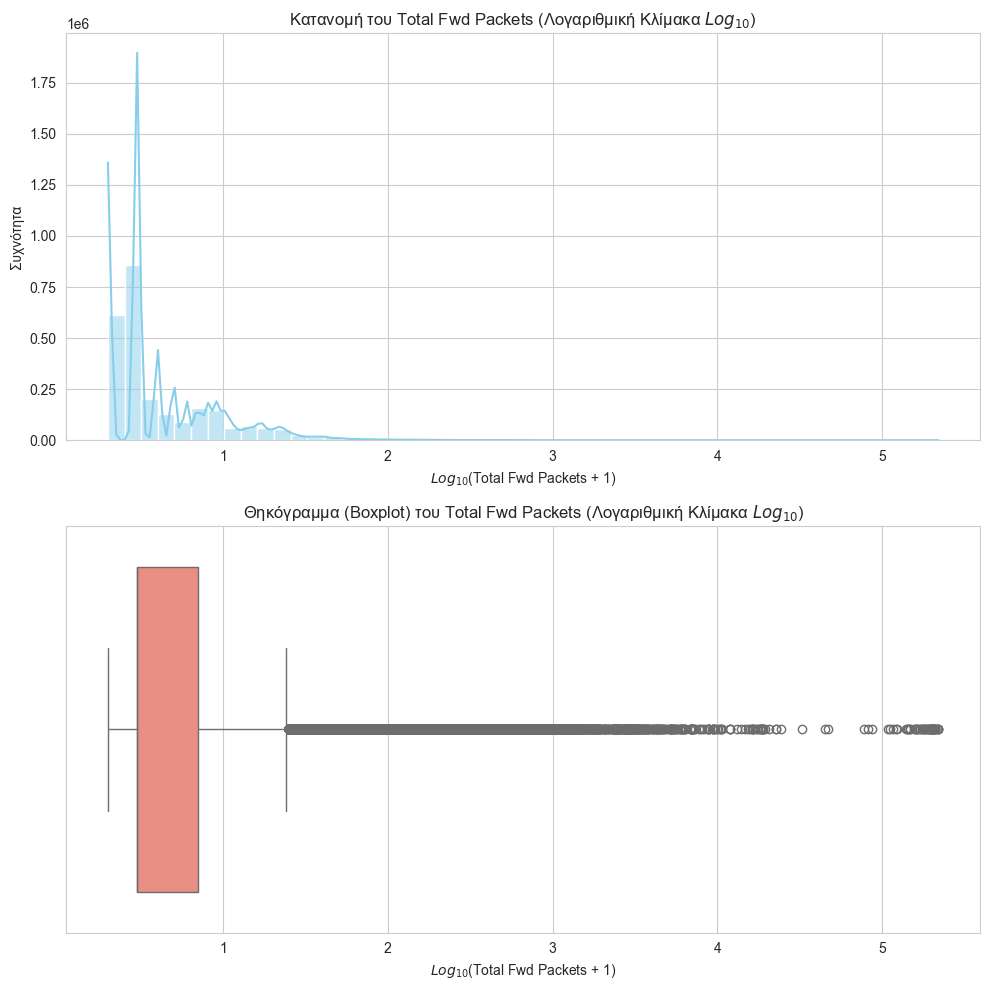

In [54]:
# ΚΕΛΙ 6.2 - Οπτικοποίηση για το Total Fwd Packets
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("ΟΠΤΙΚΟΠΟΙΗΣΗ ΧΑΡΑΚΤΗΡΙΣΤΙΚΟΥ: Total Fwd Packets")

# Υπολογισμός λογαρίθμου για σωστή οπτικοποίηση
fwd_packets_log = np.log10(df['Total Fwd Packets'] + 1)

fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# 1. Ιστόγραμμα
sns.histplot(x=fwd_packets_log, kde=True, bins=50, ax=axes[0], color='skyblue')
axes[0].set_title('Κατανομή του Total Fwd Packets (Λογαριθμική Κλίμακα $Log_{10}$)')
axes[0].set_xlabel('$Log_{10}$(Total Fwd Packets + 1)')
axes[0].set_ylabel('Συχνότητα')

# 2. Θηκόγραμμα
sns.boxplot(x=fwd_packets_log, ax=axes[1], color='salmon')
axes[1].set_title('Θηκόγραμμα (Boxplot) του Total Fwd Packets (Λογαριθμική Κλίμακα $Log_{10}$)')
axes[1].set_xlabel('$Log_{10}$(Total Fwd Packets + 1)')

plt.tight_layout()
plt.show()

1) Παρατηρήσεις
Άξονες και Συχνότητα: Στο ιστόγραμμα, ο άξονας Χ δείχνει το συνολικό πλήθος των πακέτων προς τα εμπρός σε λογαριθμική κλίμακα (Log10 από περίπου 0 έως 5.4) και ο άξονας Υ τη συχνότητα. Παρατηρούμε μια τεράστια, απότομη κορυφή spike που πλησιάζει τις 1.9x10^6 εγγραφές, δείχνοντας ότι ο κύριος όγκος των δεδομένων είναι συγκεντρωμένος σε εκείνο ακριβώς το σημείο.
Ακραία Δεξιά Ασυμμετρία (Right Skewness): H μπλε γραμμή (KDE) ξεκινά από ένα πολύ ψηλό και στενό «βουνό» στα αριστερά (κοντά στην τιμή 0.5) και πέφτει πολύ γρήγορα, σχηματίζοντας μια μακριά, φθίνουσα και κυματιστή ουρά που απλώνεται προς τα δεξιά μέχρι το 5.4.
Η Συμπεριφορά στο Boxplot: Λόγω της συγκέντρωσης των περισσότερων τιμών σε χαμηλά επίπεδα, το ροζ κουτί (που αντιπροσωπεύει το κεντρικό 50% των δεδομένων) είναι εντελώς μετατοπισμένο και περιορισμένο στα αριστερά (μεταξύ των τιμών 0.4 και 0.9). Το δεξία του γραμμή σταματά επίσης πολύ νωρίς, κοντά στο 1.4.
2) Μορφή και συγκεκριμένα μοτίβα
Μοτίβο Συσσωρευμένων Ακραίων Τιμών (Outliers): Αμέσως μετά τη δεξιά γραμμή (1.4), ξεκινάει μια εξαιρετικά μακριά, παχιά και συμπαγής μαύρη οριζόντια γραμμή που εκτείνεται αδιάκοπα μέχρι το τέρμα δεξιά (5.4). Αυτή η γραμμή σχηματίζεται από χιλιάδες συνεχόμενες τελείες ακραίων τιμών (outliers) που βρίσκονται σε απόλυτη πυκνότητα μεταξύ τους. Κοντεύοντας στο τέλος της γραμμής, οι τελείες αρχίζουν να αραιώνουν ελαφρώς, αλλά παραμένουν ενεργές.
Ερμηνεία: Αυτό το μοτίβο αποκαλύπτει δύο τελείως διαφορετικές συμπεριφορές στο δίκτυο. Η τεράστια συγκέντρωση αριστερά (τιμές κάτω από 1.0, δηλαδή λιγότερα από 10 πακέτα) αντιπροσωπεύει την τυπική, καθημερινή κίνηση όπου οι ανταλλαγές δεδομένων απαιτούν ελάχιστα πακέτα. Αντίθετα, η ατελείωτη μαύρη γραμμή των outliers στα δεξιά αποτυπώνει ροές που μεταφέρουν από εκατοντάδες έως και εκατοντάδες χιλιάδες πακέτα προς τα εμπρός (10^4 με 10^5). Στην κυβερνοασφάλεια, αυτό το μοτίβο αποτελεί την απόλυτη ένδειξη επιθέσεων Flooding και DoS/DDoS, όπου ο επιτιθέμενος «βομβαρδίζει» ασταμάτητα το θύμα με πακέτα για να εξαντλήσει το bandwidth του.

ΟΠΤΙΚΟΠΟΙΗΣΗ ΧΑΡΑΚΤΗΡΙΣΤΙΚΟΥ: Total Length of Fwd Packets


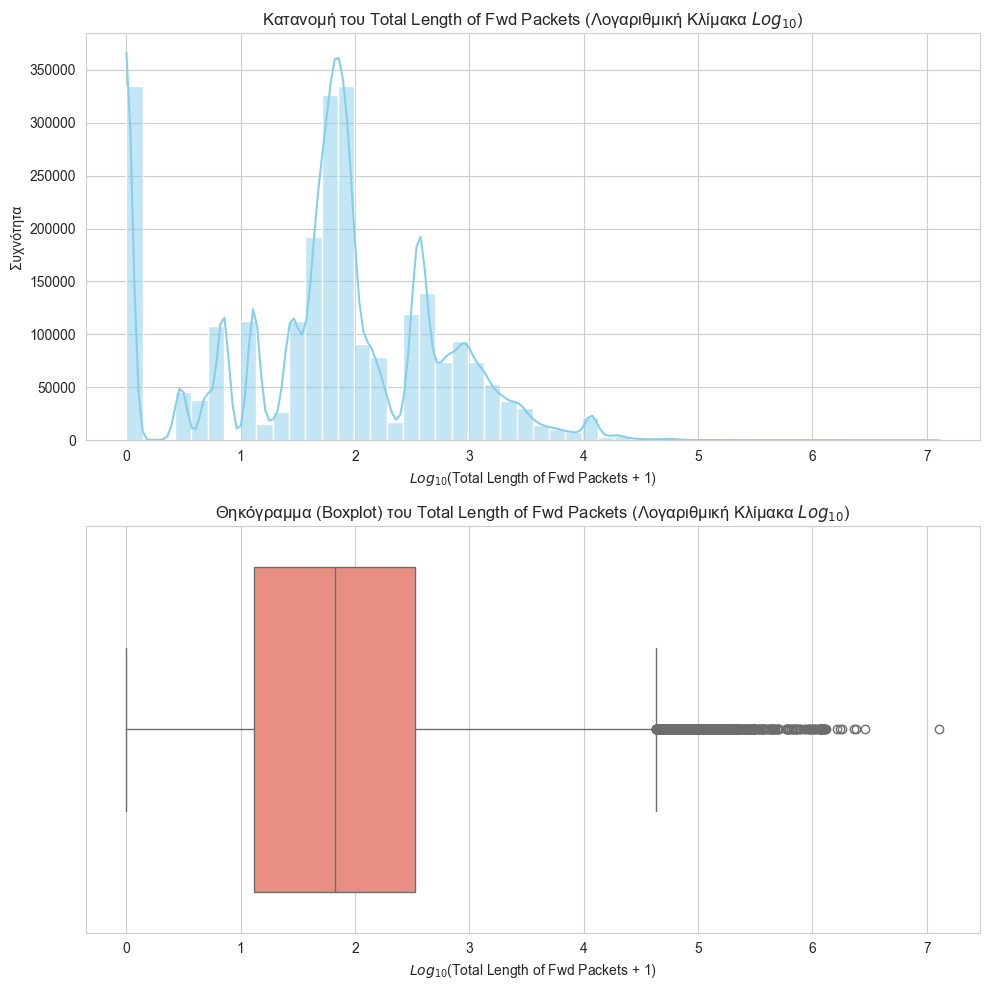

In [46]:
# ΚΕΛΙ 6.3 - Οπτικοποίηση για το Total Length of Fwd Packets
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("ΟΠΤΙΚΟΠΟΙΗΣΗ ΧΑΡΑΚΤΗΡΙΣΤΙΚΟΥ: Total Length of Fwd Packets")

fwd_length_log = np.log10(df['Total Length of Fwd Packets'] + 1)

fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# 1. Ιστόγραμμα
sns.histplot(x=fwd_length_log, kde=True, bins=50, ax=axes[0], color='skyblue')
axes[0].set_title('Κατανομή του Total Length of Fwd Packets (Λογαριθμική Κλίμακα $Log_{10}$)')
axes[0].set_xlabel('$Log_{10}$(Total Length of Fwd Packets + 1)')
axes[0].set_ylabel('Συχνότητα')

# 2. Θηκόγραμμα
sns.boxplot(x=fwd_length_log, ax=axes[1], color='salmon')
axes[1].set_title('Θηκόγραμμα (Boxplot) του Total Length of Fwd Packets (Λογαριθμική Κλίμακα $Log_{10}$)')
axes[1].set_xlabel('$Log_{10}$(Total Length of Fwd Packets + 1)')

plt.tight_layout()
plt.show()

1) Παρατηρήσεις
Άξονες και Συχνότητα: Στο ιστόγραμμα, ο άξονας Χ δείχνει τον συνολικό όγκο των πακέτων σε Bytes σε λογαριθμική κλίμακα (Log10 από 0 έως περίπου 7.1) και ο άξονας Υ τη συχνότητα. Παρατηρούμε δύο πολύ μεγάλες κορυφές spikes που ξεπερνούν τις 350.000 εγγραφές η καθεμία. Η μία είναι κολλημένη ακριβώς στο 0 (1Byte) και η άλλη βρίσκεται κοντά στο 1.8 (63Bytes).
Δεξιά Ασυμμετρία (Right Skewness) με Διακυμάνσεις: Η κατανομή παρουσιάζει δεξιά ασυμμετρία, αλλά βλέπουμε ότι η «ουρά» στα δεξιά δεν είναι επίπεδη, αλλά γεμάτη με μικρότερα διαδοχικά λοφάκια που σβήνουν σταδιακά καθώς πλησιάζουμε προς το 4.5, πριν εξαφανιστούν τελείως κοντά στο 7.1.
Η Συμπεριφορά στο Boxplot: Το ροζ κουτί (το κεντρικό 50% των δεδομένων) είναι αρκετά πλατύ και εκτείνεται από το 1.1 έως το 2.5 (12 έως 16Bytes). Η διάμεσος (Median) εντοπίζεται σχεδόν στο κέντρο του κουτιού, γύρω στο 1.8, δείχνοντας ότι η τυπική ροή μεταφέρει μερικές δεκάδες Bytes. Η δεξιά μαύρη γραμμή εκτείνεται αρκετά μακριά, φτάνοντας κοντά στο 4.6.

2) Μορφή και συγκεκριμένα μοτίβα
Πολυκορυφικό Μοτίβο: Το ιστόγραμμα αποκαλύπτει ένα έντονα πολυκορυφικό μοτίβο με πολλές διακριτές καμπούρες. Αυτό μας δείχνει ότι οι ροές στο δίκτυο χωρίζονται σε πολύ συγκεκριμένες "κατηγορίες" μεγέθους: ροές με μηδενικό/ελάχιστο φορτίο (στο 0), ροές με μικρά πακέτα ελέγχου (γύρω στο 1.0 και 1.8), και ροές μεσαίου μεγέθους δεδομένων (γύρω στο 2.6 με 3.0).
Μοτίβο Ακραίων Τιμών (Outliers) και Ερμηνεία: Μετά τη δεξιά μαύρη γραμμή (4.6), εμφανίζεται μια γραμμή από μεμονωμένες και αραιές κουκκίδες (outliers) που φτάνουν μέχρι το 7.1.
Τα παραπάνω ερμηνεύονται ως εξής: οι καμπούρες αριστερά αντιπροσωπεύουν την τυπική δραστηριότητα (μικρά πακέτα/αιτήματα ιστού). Αντίθετα, οι ακραίες τιμές στα δεξιά (outliers) προδίδουν ροές που κουβαλάνε τεράστιο όγκο δεδομένων. Αυτό το μοτίβο μπορεί να υποδεικνύει είτε επιθέσεις εξαγωγής δεδομένων (Data Exfiltration/κλοπή αρχείων), είτε κακόβουλο "Heavy Flooding" όπου ο επιτιθέμενος στέλνει επίτηδες γιγαντιαία πακέτα για να "μπουκώσει" τις υποδομές του δικτύου.

ΟΠΤΙΚΟΠΟΙΗΣΗ ΧΑΡΑΚΤΗΡΙΣΤΙΚΟΥ: Flow Packets/s


c:\Users\denni\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


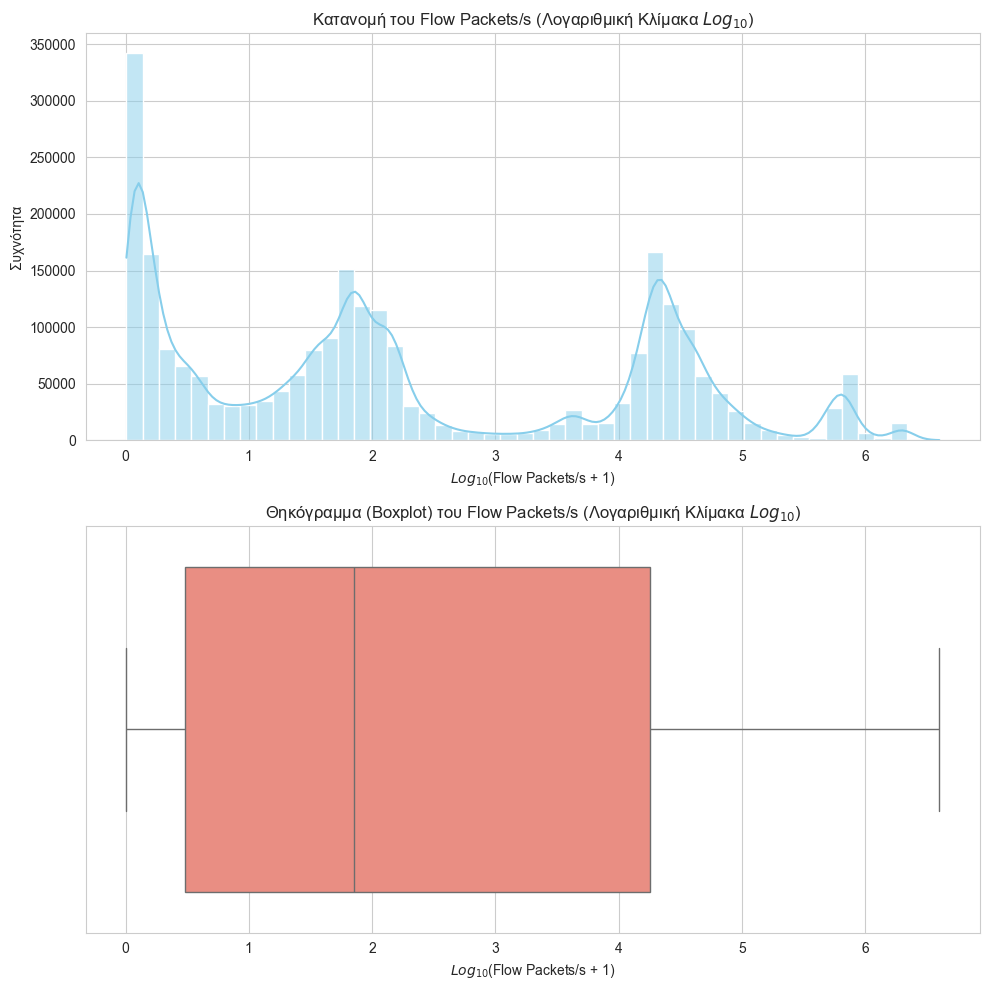

In [47]:
# ΚΕΛΙ 6.4 - Οπτικοποίηση για το Flow Packets/s
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("ΟΠΤΙΚΟΠΟΙΗΣΗ ΧΑΡΑΚΤΗΡΙΣΤΙΚΟΥ: Flow Packets/s")

# Αντικατάσταση πιθανών άπειρων τιμών (Inf) που προκύπτουν αν η διάρκεια είναι 0
df['Flow Packets/s'] = df['Flow Packets/s'].replace([np.inf, -np.inf], np.nan)
packets_per_sec_log = np.log10(df['Flow Packets/s'].dropna() + 1)

fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# 1. Ιστόγραμμα
sns.histplot(x=packets_per_sec_log, kde=True, bins=50, ax=axes[0], color='skyblue')
axes[0].set_title('Κατανομή του Flow Packets/s (Λογαριθμική Κλίμακα $Log_{10}$)')
axes[0].set_xlabel('$Log_{10}$(Flow Packets/s + 1)')
axes[0].set_ylabel('Συχνότητα')

# 2. Θηκόγραμμα
sns.boxplot(x=packets_per_sec_log, ax=axes[1], color='salmon')
axes[1].set_title('Θηκόγραμμα (Boxplot) του Flow Packets/s (Λογαριθμική Κλίμακα $Log_{10}$)')
axes[1].set_xlabel('$Log_{10}$(Flow Packets/s + 1)')

plt.tight_layout()
plt.show()

1) Παρατηρήσεις
Άξονες και Συχνότητα: Στο ιστόγραμμα, ο άξονας Χ δείχνει την ταχύτητα ροής πακέτων ανά δευτερόλεπτο σε λογαριθμική κλίμακα (Log10 από 0 έως περίπου 6.6) και ο άξονας Υ τη συχνότητα. Παρατηρούμε μια πολύ μεγάλη κορυφή (spike) στην αρχή που αγγίζει τις 340.000 εγγραφές, κολλημένη σχεδόν στο 0.1, καθώς και άλλες δύο μεγάλες κορυφές που ξεπερνούν τις 150.000 και 160.000 εγγραφές αντίστοιχα (γύρω στο 1.8 και στο 4.3).
Δεξιά Ασυμμετρία (Right Skewness) με Διακυμάνσεις: Η κατανομή παρουσιάζει δεξιά ασυμμετρία, αλλά βλέπουμε ότι η «ουρά» στα δεξιά δεν είναι επίπεδη, αλλά γεμάτη με έντονα, διαδοχικά λοφάκια και σκαμπανεβάσματα που εκτείνονται μακριά, πριν σβήσουν τελείως κοντά στο 6.6.
Η Συμπεριφορά στο Boxplot: Το ροζ κουτί (το κεντρικό 50% των δεδομένων) είναι εξαιρετικά πλατύ αυτή τη φορά και εκτείνεται από το 0.5 έως το 4.2. Η διάμεσος (Median) εντοπίζεται σχεδόν στο κέντρο του κουτιού, γύρω στο 1.8, δείχνοντας ότι ο τυπικός ρυθμός αποστολής είναι μερικές δεκάδες πακέτα/δευτερόλεπτο. Η δεξιά μαύρη γραμμή εκτείνεται πάρα πολύ μακριά, φτάνοντας μέχρι το 6.6.

2) Μορφή και συγκεκριμένα μοτίβα
Πολυκορυφικό Μοτίβο: Το ιστόγραμμα αποκαλύπτει ένα κλασικό πολυκορυφικό μοτίβο με τέσσερις πολύ διακριτές καμπούρες (στο 0.1, στο 1.8, στο 4.3 και μια μικρότερη στο 5.8). Αυτό μας δείχνει ότι η ταχύτητα των ροών στο δίκτυο χωρίζεται σε πολύ συγκεκριμένες "ταχύτητες": ροές πολύ χαμηλού ρυθμού (στο 0), ροές μεσαίας ταχύτητας (στο 1.8 και 4.3), και ροές εξαιρετικά υψηλής ταχύτητας (κοντά στο 5.8).
Μοτίβο Ακραίων Τιμών (Outliers) και Ερμηνεία: Στο συγκεκριμένο boxplot παρατηρούμε μια σημαντική ιδιαιτερότητα: δεν εμφανίζονται καθόλου μεμονωμένες κουκκίδες (outliers) μετά τη δεξιά μαύρη γραμμή, καθώς έχει απλωθεί και καλύπτει όλο το εύρος μέχρι το 6.6.
Ερμηνεία: Τα παραπάνω ερμηνεύονται ως εξής: οι καμπούρες αριστερά και στη μέση αντιπροσωπεύουν την τυπική δραστηριότητα και τους φυσιολογικούς ρυθμούς ανταλλαγής πακέτων των χρηστών. Αντίθετα, οι υψηλές τιμές στα δεξιά (γύρω στο 4.3 έως 6.6, που σημαίνει 10^4 έως 10^6 πακέτα το δευτερόλεπτο) προδίδουν ροές με καταιγιστικό ρυθμό αποστολής. Επειδή αυτές οι ακραία υψηλές ταχύτητες δεν εμφανίζονται ως σκόρπιες τελείες αλλά ως συμπαγή, μεγάλα λοφάκια στο ιστόγραμμα, αποτελούν την απόλυτη ένδειξη για οργανωμένες επιθέσεις Flooding ή DoS/DDoS, όπου ο επιτιθέμενος προσπαθεί να "γονατίσει" τον server στέλνοντας εκατομμύρια πακέτα σε χρόνο μηδέν.

ΟΠΤΙΚΟΠΟΙΗΣΗ ΧΑΡΑΚΤΗΡΙΣΤΙΚΟΥ: Flow IAT Mean


c:\Users\denni\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\denni\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


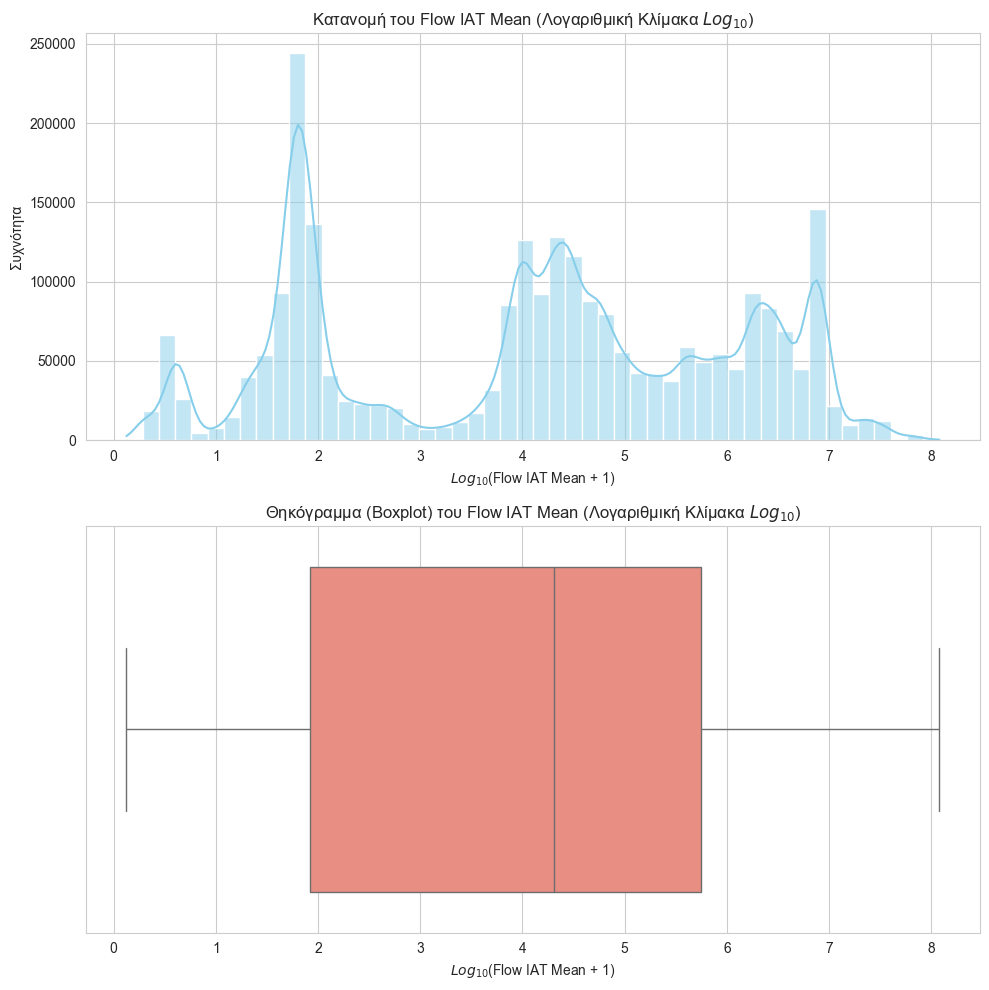

In [48]:
# ΚΕΛΙ 6.5 - Οπτικοποίηση για το Flow IAT Mean
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("ΟΠΤΙΚΟΠΟΙΗΣΗ ΧΑΡΑΚΤΗΡΙΣΤΙΚΟΥ: Flow IAT Mean")

iat_mean_log = np.log10(df['Flow IAT Mean'] + 1)

fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# 1. Ιστόγραμμα
sns.histplot(x=iat_mean_log, kde=True, bins=50, ax=axes[0], color='skyblue')
axes[0].set_title('Κατανομή του Flow IAT Mean (Λογαριθμική Κλίμακα $Log_{10}$)')
axes[0].set_xlabel('$Log_{10}$(Flow IAT Mean + 1)')
axes[0].set_ylabel('Συχνότητα')

# 2. Θηκόγραμμα
sns.boxplot(x=iat_mean_log, ax=axes[1], color='salmon')
axes[1].set_title('Θηκόγραμμα (Boxplot) του Flow IAT Mean (Λογαριθμική Κλίμακα $Log_{10}$)')
axes[1].set_xlabel('$Log_{10}$(Flow IAT Mean + 1)')

plt.tight_layout()
plt.show()

1) Παρατηρήσεις
Άξονες και Συχνότητα: Στο ιστόγραμμα, ο άξονας Χ δείχνει τον μέσο χρόνο μεταξύ της άφιξης των πακέτων (Flow Inter-Arrival Time Mean) σε λογαριθμική κλίμακα (Log10 από 0 έως περίπου 8.1) και ο άξονας Υ τη συχνότητα. Παρατηρούμε μια πολύ υψηλή, απόλυτη κορυφή (spike) που ξεπερνά τις 240.000 εγγραφές κοντά στην τιμή 1.8, καθώς και άλλες τρεις μεγάλες, διακριτές κορυφές που κυμαίνονται μεταξύ 100.000 και 130.000 εγγραφών (γύρω στο 4.3, 6.3 και 6.9).
Δεξιά Ασυμμετρία (Right Skewness) με Διακυμάνσεις: Η κατανομή παρουσιάζει δεξιά ασυμμετρία, αλλά ο λογάριθμος αποκαλύπτει ότι η «ουρά» στα δεξιά είναι εξαιρετικά έντονη, γεμάτη με μεγάλα, διαδοχικά λοφάκια και σκαμπανεβάσματα που εκτείνονται μέχρι το τέρμα δεξιά, πριν σβήσουν τελείως κοντά στο 8.1.
Η Συμπεριφορά στο Boxplot: Το ροζ κουτί (το κεντρικό 50% των δεδομένων) είναι πάρα πολύ πλατύ και καταλαμβάνει το μεγαλύτερο μέρος του γραφήματος, εκτεινόμενο από το 1.9 έως το 5.7. Η διάμεσος (Median) εντοπίζεται σχεδόν στο κέντρο του κουτιού, γύρω στο 4.3. Η δεξιά μαύρη γραμμή (το δεξί μουστάκι) εκτείνεται μέχρι το ανώτατο όριο της κατανομής, κοντά στο 8.1.

2) Μορφή και συγκεκριμένα μοτίβα
Πολυκορυφικό Μοτίβο: Το ιστόγραμμα αποκαλύπτει ένα πολύ καθαρό πολυκορυφικό μοτίβο με τέσσερις κύριες καμπούρες (στο 1.8, στο 4.3, στο 6.3 και στο 6.9), καθώς και μια μικρότερη στην αρχή (γύρω στο 0.6). Αυτό μας δείχνει ότι οι καθυστερήσεις μεταξύ των πακέτων διαχωρίζονται σε πολύ συγκεκριμένες χρονικές κλάσεις: από εξαιρετικά μικρές (μικρότερες από millisecond), σε μεσαίες, έως και πολύ μεγάλες (δευτερόλεπτα ή λεπτά).
Μοτίβο Ακραίων Τιμών (Outliers) και Ερμηνεία: Όπως και στο προηγούμενο χαρακτηριστικό, στο boxplot δεν εμφανίζονται καθόλου μεμονωμένες κουκκίδες (outliers), καθώς η δεξιά μαύρη γραμμή απλώνεται και ενσωματώνει όλο το εύρος των μεγάλων τιμών μέχρι το 8.1.
Ερμηνεία: Τα παραπάνω ερμηνεύονται ως εξής: η πρώτη μεγάλη καμπούρα αριστερά (γύρω στο 1.8, δηλαδή μερικά milliseconds) προδίδει ροές με πολύ γρήγορη και συνεχή αποστολή πακέτων. Ένας πολύ μικρός μέσος χρόνος μεταξύ των πακέτων αποτελεί κλασικό αποτύπωμα επιθέσεων DoS/DDoS Flooding, όπου τα πακέτα στέλνονται ακατάπαυστα το ένα πίσω από το άλλο για να εξαντλήσουν τους πόρους. Αντίθετα, οι καμπούρες στα δεξιά (από 4.3 έως 7.0, που σημαίνει από αρκετά δευτερόλεπτα έως και λεπτά καθυστέρησης) αντιπροσωπεύουν είτε την τυπική, σκόρπια δραστηριότητα των απλών χρηστών (π.χ. ανάγνωση μιας σελίδας), είτε επιθέσεις τύπου "Slowloris" / Slow DoS, οι οποίες στέλνουν πακέτα πολύ αργά και μεθοδικά για να κρατούν τις γραμμές του server απασχολημένες χωρίς να γίνονται εύκολα αντιληπτές από τα συστήματα ασφαλείας.


LABEL DISTRIBUTION TABLE:

                     Label  Total Count  Percentage (%)     Percentage (%)
                    BENIGN      2095057       83.110864              83.11
                  DoS Hulk       172846        6.856797               6.86
                      DDoS       128014        5.078313               5.08
                  PortScan        90694        3.597829               3.60
             DoS GoldenEye        10286        0.408045               0.41
               FTP-Patator         5931        0.235283               0.24
             DoS slowloris         5385        0.213623               0.21
          DoS Slowhttptest         5228        0.207395               0.21
               SSH-Patator         3219        0.127698               0.13
                       Bot         1948        0.077277               0.08
  Web Attack - Brute Force         1470        0.058315               0.06
          Web Attack - XSS          652        0.025865               0.

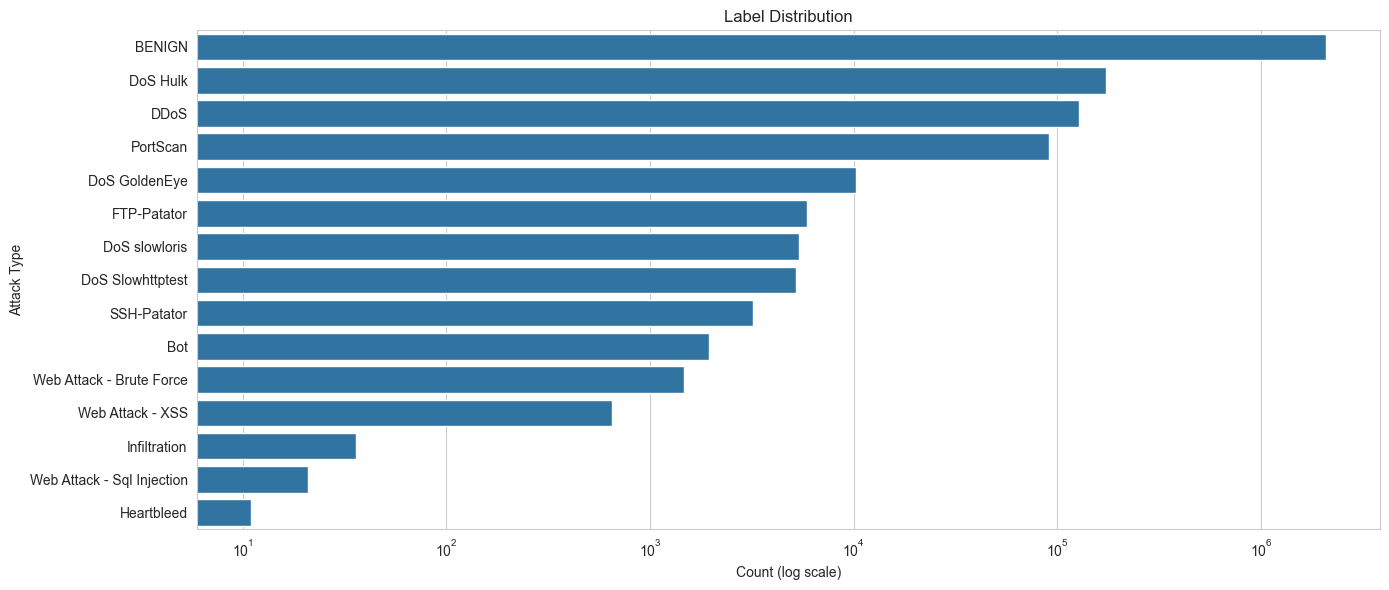

In [43]:
# ΚΕΛΙ 7

# Αντικατάσταση προβληματικών χαρακτήρων ("?" και "□") με "-"
df['Label'] = (
    df['Label']
    .astype(str)
    .str.replace('?', '-', regex=False)
    .str.replace('�', '-', regex=False)
    .str.replace('□', '-', regex=False)
)

# Υπολογισμός counts και percentages
label_counts = df['Label'].value_counts()
label_percentages = df['Label'].value_counts(normalize=True) * 100

# Δημιουργία πίνακα
label_table = pd.DataFrame({
    'Label': label_counts.index,
    'Total Count': label_counts.values,
    'Percentage (%)': label_percentages.values
})

# Μορφοποίηση ποσοστών
label_table['Percentage (%)'] = label_table['Percentage (%)'].round(2)

# Εμφάνιση ΟΛΟΚΛΗΡΟΥ πίνακα χωρίς "..."
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# Εμφάνιση πίνακα
print("\nLABEL DISTRIBUTION TABLE:\n")
print(label_table.to_string(index=False))

plt.figure(figsize=(14,6))

sns.countplot(
    y=df['Label'],
    order=df['Label'].value_counts().index
)

plt.xscale('log')

plt.title("Label Distribution")
plt.xlabel("Count (log scale)")
plt.ylabel("Attack Type")

plt.tight_layout()
plt.show()

Class Imbalance: Η στήλη Label παρουσιάζει έντονη ανισορροπία κλάσεων , καθώς τα στιγμιότυπα BENIGN (83,11%) υπερτερούν αριθμητικά από όλα τα υπόλοιπα (16,89%).

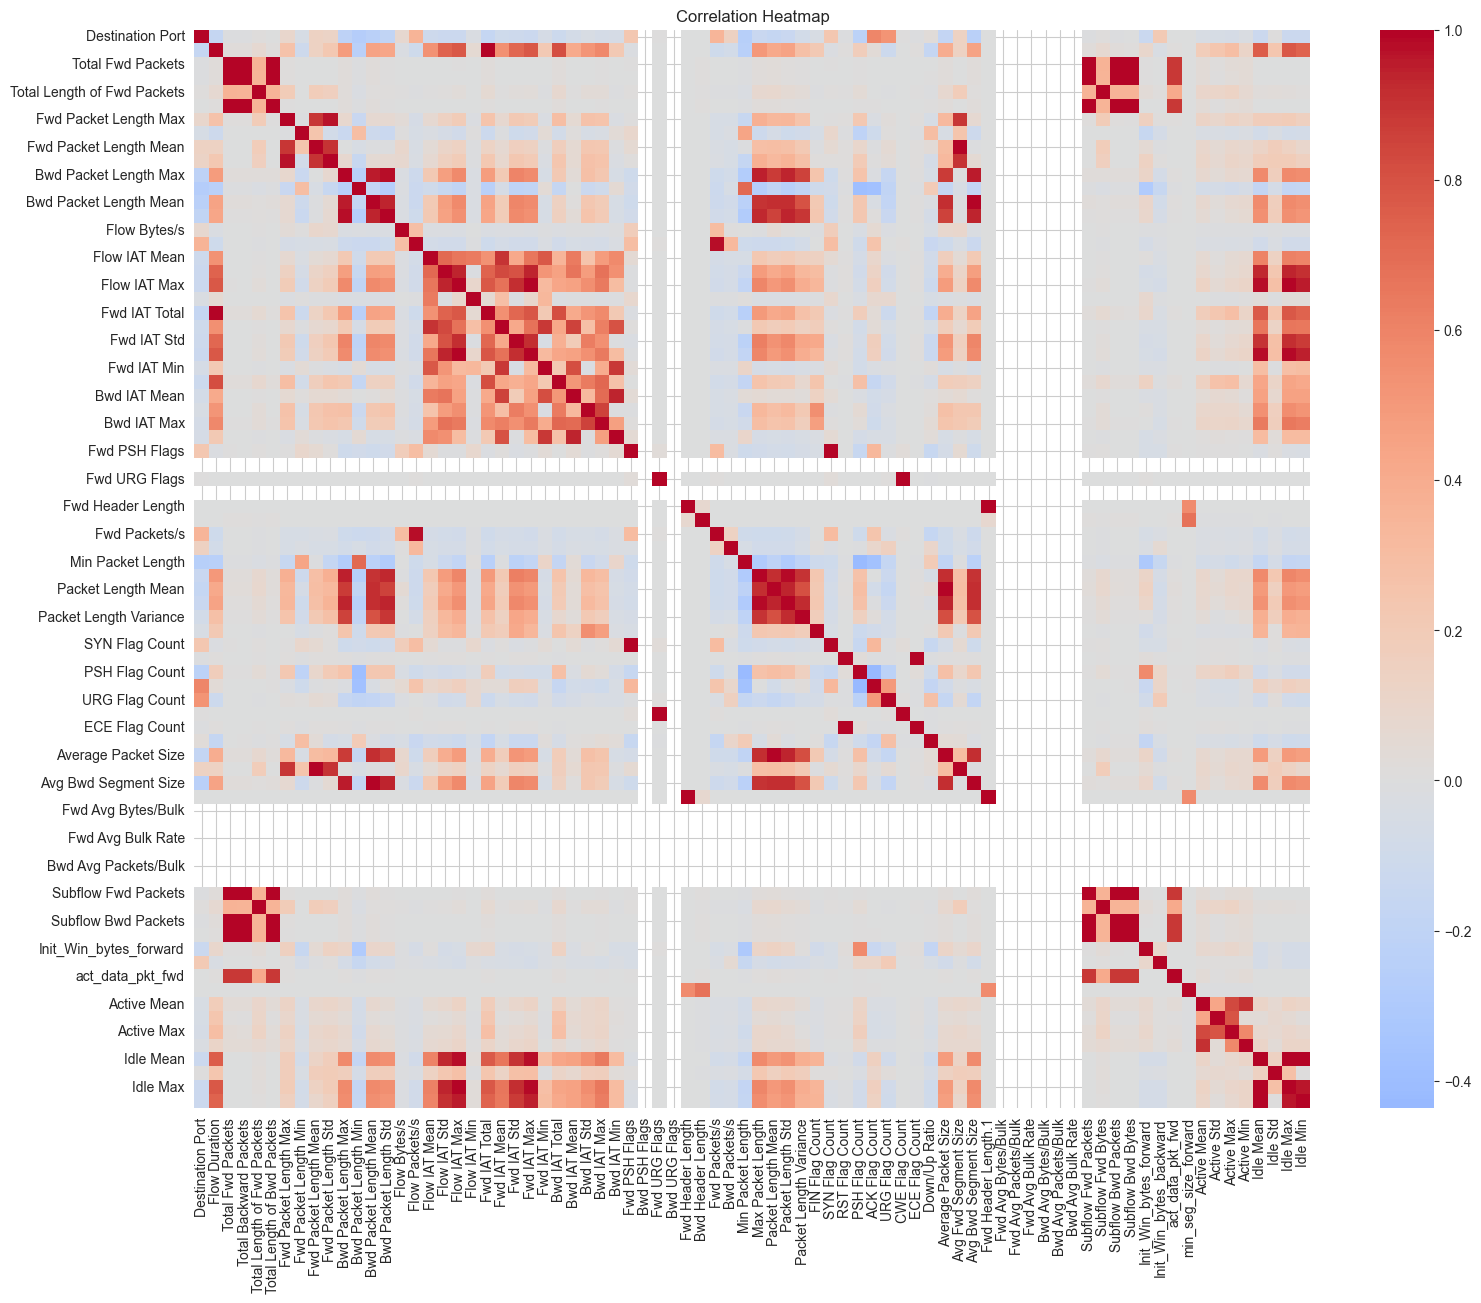

In [ ]:
# ΚΕΛΙ 8

numeric_df = df.select_dtypes(include=np.number)

corr_matrix = numeric_df.corr()

plt.figure(figsize=(18,14))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0
)

plt.title("Correlation Heatmap")

plt.show()

Το γράφημα βασίζεται στον Συντελεστή Συσχέτισης του Pearson (r). Κάθε τετράγωνο στο πλέγμα αντιπροσωπεύει τη σχέση μεταξύ της μεταβλητής της γραμμής και της μεταβλητής της στήλης. Οι τιμές αυτού του συντελεστή κυμαίνονται αυστηρά από -1 έως +1 και το χρώμα μας δείχνει το αποτέλεσμα:
Τέλεια Θετική Συσχέτιση (r περίπου 1 /Έντονο Κόκκινο): Σημαίνει ότι οι δύο μεταβλητές είναι ανάλογες, όταν η μία αυξάνεται, η άλλη αυξάνεται σχεδόν αυτόματα και αναλογικά.
Καμία Συσχέτιση (r περίπου 0 /Ανοιχτό Γκρι-Λευκό): Σημαίνει ότι οι δύο μεταβλητές είναι εντελώς ανεξάρτητες. Το τι κάνει η μία δεν επηρεάζει καθόλου την άλλη.
Αρνητική Συσχέτιση (r περίπου -0.2 /Ανοιχτό Μπλε): Σημαίνει ότι οι μεταβλητές κινούνται αντίθετα. Όταν η μία ανεβαίνει, η άλλη πέφτει.

Η Κόκκινη Διαγώνιος: Είναι η γραμμή που ξεκινάει από πάνω αριστερά και καταλήγει κάτω δεξιά. Έχει παντού την τιμή 1 (κόκκινη), επειδή προκύπτει από τη συσχέτιση κάθε μεταβλητής με τον ίδιο της τον εαυτό (π.χ. το Flow Duration με το Flow Duration).

Τα Συμπαγή Κόκκινα Τετράγωνα (Clusters): Τα κόκκινα κουτάκια δεν είναι διάσπαρτα, αλλά σχηματίζουν ολόκληρα τετράγωνα «μπλοκ». Αυτό στατιστικά σημαίνει ότι ολόκληρες ομάδες μεταβλητών κινούνται με τον ίδιο ακριβώς ρυθμό και μεταφέρουν, ουσιαστικά, την ίδια πληροφορία.

Οι Γκρίζες Λωρίδες (Dead Zones): Υπάρχουν κάποιες οριζόντιες και κάθετες γραμμές (όπως στο Fwd URG Flags ή στα Bulk πεδία) που είναι εντελώς γκρίζες ή λευκές. Αυτό σημαίνει ότι οι συγκεκριμένες στήλες στο dataset έχουν παντού την ίδια τιμή (π.χ. είναι όλες 0). Επειδή δεν αλλάζουν ποτέ (δεν έχουν variance), τα μαθηματικά δεν μπορούν να βρουν καμία συσχέτιση με τίποτα άλλο.

In [ ]:
# ΚΕΛΙ 9
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_features = [
    column for column in upper.columns
    if any(upper[column] > 0.95)
]

print("Highly Correlated Features:")
print(high_corr_features)

Highly Correlated Features:
['Total Backward Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Std', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Fwd IAT Total', 'Fwd IAT Max', 'Fwd Packets/s', 'Packet Length Std', 'SYN Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Average Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Fwd Header Length.1', 'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes', 'Idle Mean', 'Idle Max', 'Idle Min']


Ο κώδικας χρησιμοποιείται για τον εντοπισμό χαρακτηριστικών με πολύ υψηλή συσχέτιση, ώστε να αναγνωριστούν πιθανές πλεονάζουσες μεταβλητές που μεταφέρουν σχεδόν την ίδια πληροφορία.

In [ ]:
#ΚΕΛΙ 10
selector = VarianceThreshold(threshold=0.01)

selector.fit(numeric_df)

low_variance_features = numeric_df.columns[
    ~selector.get_support()
]

print("Low Variance Features:")
print(list(low_variance_features))

Low Variance Features:
['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'RST Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']


Αφαίρεση Χαρακτηριστικών Χαμηλής Διακύμανσης

Εφαρμόστηκε η μέθοδος Variance Threshold για τον εντοπισμό χαρακτηριστικών με πολύ χαμηλή διακύμανση. Οι μεταβλητές αυτές παρουσιάζουν σχεδόν σταθερές τιμές σε όλο το dataset και επομένως δεν συμβάλλουν ουσιαστικά στη διάκριση μεταξύ διαφορετικών κλάσεων.

Η αφαίρεσή τους είναι σημαντική διότι: 
 μειώνει την πολυπλοκότητα του dataset,
 αφαιρεί μη πληροφοριακά χαρακτηριστικά,
 και βελτιώνει την απόδοση και σταθερότητα των μοντέλων μηχανικής μάθησης.

In [ ]:
# ΚΕΛΙ 11
features_to_drop = list(high_corr_features) + list(low_variance_features)

features_to_drop = list(set(features_to_drop))

print("Features to remove:")
print(features_to_drop)

df_reduced = df.drop(columns=features_to_drop)

print("\nOriginal Shape:", df.shape)
print("Reduced Shape:", df_reduced.shape)

Features to remove:
['Average Packet Size', 'Packet Length Std', 'RST Flag Count', 'Subflow Fwd Bytes', 'Fwd Packet Length Std', 'CWE Flag Count', 'ECE Flag Count', 'Fwd Packets/s', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Subflow Bwd Packets', 'SYN Flag Count', 'Subflow Bwd Bytes', 'Avg Fwd Segment Size', 'Idle Mean', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Idle Max', 'Total Length of Bwd Packets', 'Fwd URG Flags', 'Idle Min', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd IAT Total', 'Fwd Avg Bulk Rate', 'Total Backward Packets', 'Fwd IAT Max', 'Bwd Avg Bulk Rate', 'Bwd PSH Flags', 'Fwd Avg Packets/Bulk', 'Fwd Header Length.1', 'Avg Bwd Segment Size', 'Subflow Fwd Packets']

Original Shape: (2520798, 79)
Reduced Shape: (2520798, 46)


Τελική Επιλογή και Αφαίρεση Χαρακτηριστικών

Στο τελικό στάδιο της ανάλυσης συνδυάστηκαν τα αποτελέσματα από την ανάλυση συσχέτισης και τον έλεγχο διακύμανσης, ώστε να εντοπιστούν χαρακτηριστικά που είτε είναι πλεονάζοντα είτε δεν περιέχουν επαρκή πληροφορία.

Συγκεκριμένα αφαιρέθηκαν:

χαρακτηριστικά με πολύ υψηλή συσχέτιση (redundant features),
χαρακτηριστικά με πολύ χαμηλή διακύμανση (low information gain).

Η δημιουργία ενός μειωμένου συνόλου δεδομένων συμβάλλει:

στη μείωση της πολυπλοκότητας,
στη βελτίωση της αποδοτικότητας των μοντέλων,
και στην αποφυγή πολυπλοκότητας λόγω πολυσυσχέτισης (multicollinearity).

Η σύγκριση των διαστάσεων πριν και μετά την αφαίρεση δείχνει τη σημαντική μείωση του αριθμού των χαρακτηριστικών, χωρίς σημαντική απώλεια πληροφορίας.

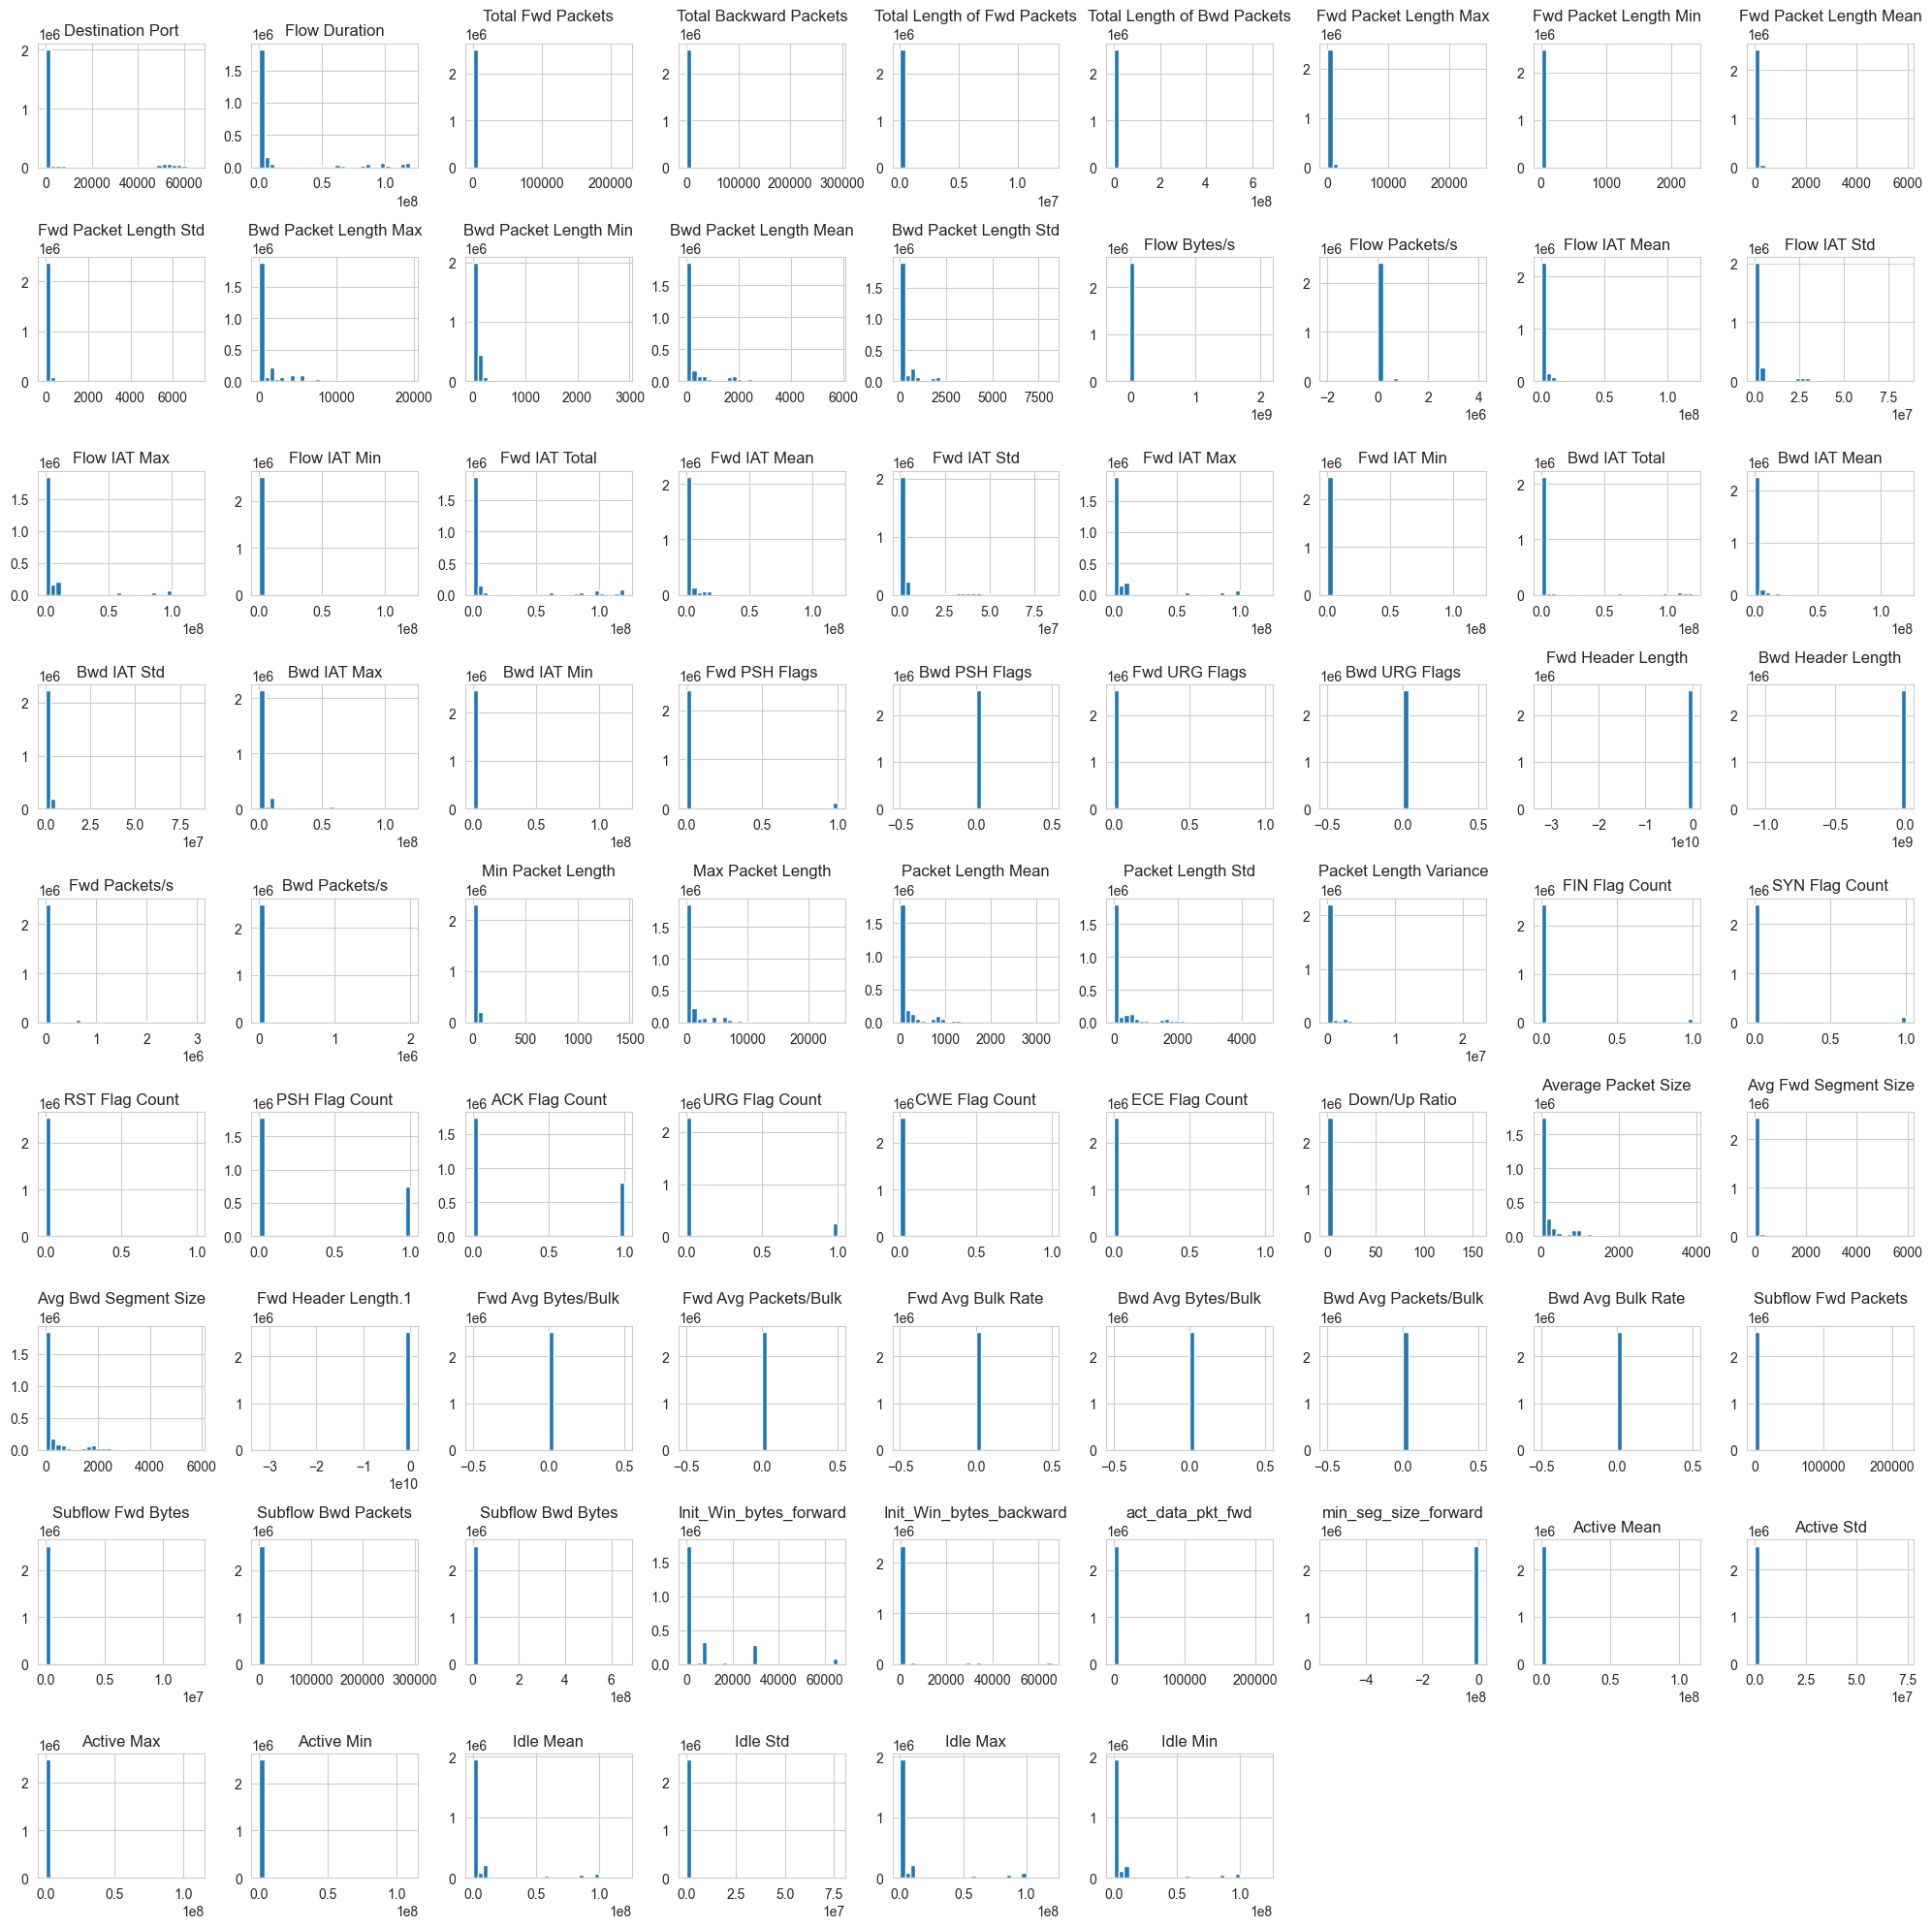

In [ ]:
# ΚΕΛΙ 12
numeric_df.hist(
    figsize=(20,20),
    bins=30
)

plt.tight_layout()
plt.show()

Κατανομές όλων των Αριθμητικών Χαρακτηριστικών

Για την συνολική διερεύνηση των κατανομών εφαρμόστηκαν ιστογράμματα σε όλες τις αριθμητικές μεταβλητές του dataset.

Από την ανάλυση παρατηρείται ότι η πλειοψηφία των χαρακτηριστικών παρουσιάζει έντονη δεξιά ασυμμετρία (right-skewed distributions), με συγκέντρωση τιμών σε χαμηλές περιοχές και εκτεταμένες ουρές προς μεγαλύτερες τιμές.

Το μοτίβο αυτό είναι χαρακτηριστικό σε δεδομένα δικτυακής κίνησης, όπου η πλειοψηφία των ροών είναι μικρής διάρκειας και χαμηλού όγκου, ενώ ένα μικρό ποσοστό ροών αντιστοιχεί σε ασυνήθιστη ή κακόβουλη δραστηριότητα.